# Preprocesamiento — La Paz Traffic

Construye la matriz de features para el clustering a partir de los 72 archivos históricos recolectados.

- **Filas**: 250 segmentos viales
- **Columnas**: `jam_factor` promedio por tipo de día (lunes/viernes/sábado) y hora (0-23) → 72 features
- **Salida**: `data/processed/feature_matrix.csv` + versión normalizada + scaler

## 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

DATA_RAW       = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(exist_ok=True)

TIPOS_DIA = ['lunes', 'viernes', 'sabado']
print('Configuración lista')

Configuración lista


## 2. Carga de datos brutos

In [2]:
def load_all_raw(data_dir):
    partes = []
    for tipo_dia in TIPOS_DIA:
        for hora in range(24):
            fpath = data_dir / f'traffic_{tipo_dia}_{hora:02d}.csv'
            if not fpath.exists():
                print(f'  FALTA: {fpath.name}')
                continue
            df = pd.read_csv(fpath)
            df['tipo_dia'] = tipo_dia
            df['hora'] = hora
            partes.append(df)

    resultado = pd.concat(partes, ignore_index=True)

    print(f'Total registros cargados : {len(resultado):,}')
    print(f'Segmentos únicos         : {resultado["segment_id"].nunique()}')
    print(f'Tipos de día             : {sorted(resultado["tipo_dia"].unique())}')
    print(f'Horas cubiertas          : {sorted(resultado["hora"].unique())}')
    print(f'NaN en jam_factor        : {resultado["jam_factor"].isna().sum()}')
    return resultado

df_raw = load_all_raw(DATA_RAW)
df_raw.head(3)

Total registros cargados : 18,000
Segmentos únicos         : 250
Tipos de día             : ['lunes', 'sabado', 'viernes']
Horas cubiertas          : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
NaN en jam_factor        : 0


,segment_id,street_name,speed_current,speed_free,jam_factor,timestamp,lat,lon,highway,tipo_dia,hora
0,0,NaN,15.7,15.28,0.0,2026-05-25 00:00:00-04:00,-16.517571,-68.051592,residential,lunes,0
1,1,NaN,0.0,0.00,0.0,2026-05-25 00:00:00-04:00,-16.533906,-68.129547,residential,lunes,0
2,2,NaN,21.6,21.60,0.0,2026-05-25 00:00:00-04:00,-16.518653,-68.056460,residential,lunes,0


## 3. Construcción de la matriz de features

In [3]:
def build_feature_matrix(df):
    pivot = df.pivot_table(
        index='segment_id',
        columns=['tipo_dia', 'hora'],
        values='jam_factor',
        aggfunc='mean'
    )

    # Ordenar columnas: lunes 0-23, viernes 0-23, sabado 0-23
    cols_ordenadas = [(dia, h) for dia in TIPOS_DIA for h in range(24)]
    pivot = pivot.reindex(columns=cols_ordenadas)

    # Aplanar nombres de columnas
    pivot.columns = [f'jam_{dia}_{h:02d}' for dia, h in pivot.columns]
    pivot.index.name = 'segment_id'

    pivot.to_csv(DATA_PROCESSED / 'feature_matrix.csv')
    print(f'Shape de la matriz: {pivot.shape}')
    print(f'NaN totales: {pivot.isna().sum().sum()}')
    print(f'Guardada en: data/processed/feature_matrix.csv')
    return pivot

feature_matrix = build_feature_matrix(df_raw)
feature_matrix.head(3)

Shape de la matriz: (250, 72)
NaN totales: 0
Guardada en: data/processed/feature_matrix.csv


,jam_lunes_00,jam_lunes_01,jam_lunes_02,jam_lunes_03,jam_lunes_04,jam_lunes_05,jam_lunes_06,jam_lunes_07,jam_lunes_08,jam_lunes_09,...,jam_sabado_14,jam_sabado_15,jam_sabado_16,jam_sabado_17,jam_sabado_18,jam_sabado_19,jam_sabado_20,jam_sabado_21,jam_sabado_22,jam_sabado_23
segment_id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Normalización

In [4]:
def normalize(feature_matrix):
    # Imputar NaN con la media de cada columna
    imputer = SimpleImputer(strategy='mean')
    X_imp = imputer.fit_transform(feature_matrix)

    # Escalar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    # Guardar scaler
    with open(DATA_PROCESSED / 'scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    # DataFrame con índice y columnas originales
    df_scaled = pd.DataFrame(
        X_scaled,
        index=feature_matrix.index,
        columns=feature_matrix.columns
    )
    df_scaled.to_csv(DATA_PROCESSED / 'feature_matrix_scaled.csv')

    print(f'Scaler guardado: data/processed/scaler.pkl')
    print(f'Matriz escalada guardada: data/processed/feature_matrix_scaled.csv')
    print(f'Media global post-scaling : {X_scaled.mean():.6f} (esperado ≈ 0)')
    print(f'Std global post-scaling   : {X_scaled.std():.6f} (esperado ≈ 1)')
    return df_scaled

feature_matrix_scaled = normalize(feature_matrix)

Scaler guardado: data/processed/scaler.pkl
Matriz escalada guardada: data/processed/feature_matrix_scaled.csv
Media global post-scaling : -0.000000 (esperado ≈ 0)
Std global post-scaling   : 1.000000 (esperado ≈ 1)


## 5. Reporte de calidad

In [5]:
# Cobertura
nan_pct = feature_matrix.isna().mean() * 100
print(f'Columnas con NaN: {(nan_pct > 0).sum()} de {len(nan_pct)}')
print(f'Segmentos con cobertura < 30%: {(feature_matrix.isna().mean(axis=1) > 0.7).sum()}')

# jam_factor promedio por segmento
jam_mean = feature_matrix.mean(axis=1).sort_values(ascending=False)

print('\nTop 10 segmentos más congestionados:')
seg_info = pd.read_csv(DATA_RAW / 'sample_segments.csv').set_index('segment_id')
top10 = jam_mean.head(10).reset_index()
top10.columns = ['segment_id', 'jam_promedio']
top10['highway'] = top10['segment_id'].map(seg_info['highway'])
print(top10.to_string(index=False))

print('\nTop 10 segmentos menos congestionados:')
bot10 = jam_mean.tail(10).reset_index()
bot10.columns = ['segment_id', 'jam_promedio']
bot10['highway'] = bot10['segment_id'].map(seg_info['highway'])
print(bot10.to_string(index=False))

Columnas con NaN: 0 de 72
Segmentos con cobertura < 30%: 0

Top 10 segmentos más congestionados:
 segment_id  jam_promedio     highway
        220      2.101472    tertiary
        100      1.635806 residential
        206      1.469778   secondary
         23      1.083333 residential
         17      0.957375 residential
        224      0.925833    tertiary
        216      0.902861    tertiary
        244      0.818778       trunk
        210      0.805569   secondary
         76      0.752264 residential

Top 10 segmentos menos congestionados:
 segment_id  jam_promedio       highway
        197           0.0     secondary
        225           0.0      tertiary
        226           0.0      tertiary
        219           0.0      tertiary
        222           0.0      tertiary
        237           0.0       primary
        245           0.0         trunk
        243           0.0  unclassified
        242           0.0  unclassified
        249           0.0 tertiary_link


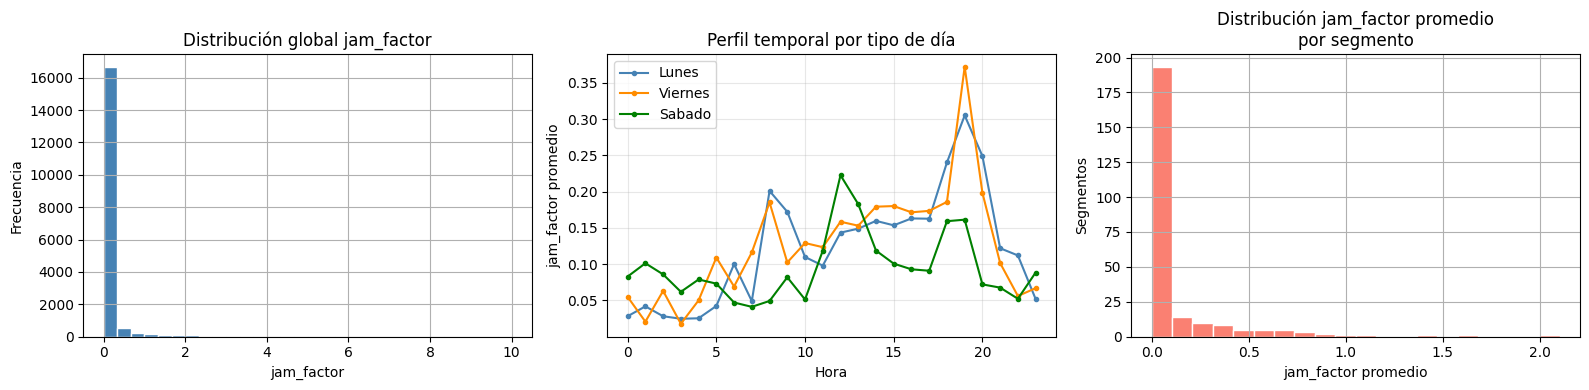

Reporte guardado: data/processed/preprocessing_report.png

=== Validación de patrones ===
lunes: rush(7-9h)=0.141 > madrugada(2-3h)=0.026 → True
viernes: rush(7-9h)=0.135 > madrugada(2-3h)=0.040 → True
sabado: rush(7-9h)=0.057 > madrugada(2-3h)=0.074 → False


In [6]:
# Gráficos de calidad
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución global de jam_factor
df_raw['jam_factor'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución global jam_factor')
axes[0].set_xlabel('jam_factor')
axes[0].set_ylabel('Frecuencia')

# Perfil temporal promedio por tipo de día
colores = {'lunes': 'steelblue', 'viernes': 'darkorange', 'sabado': 'green'}
for dia in TIPOS_DIA:
    cols = [f'jam_{dia}_{h:02d}' for h in range(24)]
    perfil = feature_matrix[cols].mean(axis=0).values
    axes[1].plot(range(24), perfil, marker='o', markersize=3,
                 label=dia.capitalize(), color=colores[dia])
axes[1].set_title('Perfil temporal por tipo de día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('jam_factor promedio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Distribución del jam promedio por segmento
jam_mean.hist(bins=20, ax=axes[2], color='salmon', edgecolor='white')
axes[2].set_title('Distribución jam_factor promedio\npor segmento')
axes[2].set_xlabel('jam_factor promedio')
axes[2].set_ylabel('Segmentos')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'preprocessing_report.png', dpi=120, bbox_inches='tight')
plt.show()
print('Reporte guardado: data/processed/preprocessing_report.png')

# Verificación de patrón esperado
print('\n=== Validación de patrones ===')
for dia in TIPOS_DIA:
    rush = feature_matrix[[f'jam_{dia}_07', f'jam_{dia}_08', f'jam_{dia}_09']].mean(axis=1).mean()
    madrugada = feature_matrix[[f'jam_{dia}_02', f'jam_{dia}_03']].mean(axis=1).mean()
    print(f'{dia}: rush(7-9h)={rush:.3f} > madrugada(2-3h)={madrugada:.3f} → {rush > madrugada}')

## 6. Resumen

Matriz de features lista para la siguiente fase.

- `data/processed/feature_matrix.csv` — (250, 72) sin normalizar
- `data/processed/feature_matrix_scaled.csv` — (250, 72) normalizada (media=0, std=1)
- `data/processed/scaler.pkl` — StandardScaler para aplicar a nuevos datos

Próximo paso: **FASE 6 — Reducción de dimensionalidad** (PCA + UMAP)